In [2]:
#Import des bibliotheques et chargement des donnees

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("anssi_cve_consolidated.csv", sep = ";")
print(f"Donnees: {df.shape}")

Donnees: (1282, 10)


In [3]:
#Nettoyage initial 

df['CVSS Score'] = pd.to_numeric(df['CVSS Score'], errors = 'coerce')
df['EPSS Score'] = pd.to_numeric(df['EPSS Score'], errors = 'coerce')

def extract_vendor(title):
    title_lower = str(title).lower()
    vendors = {
        'Microsoft': ['microsoft', 'windows', 'office', 'exchange'],
        'Cisco': ['cisco'],
        'SAP': ['sap'],
        'Adobe': ['adobe'],
        'Google': ['google', 'chrome'],
        'Linux': ['linux', 'kernel'],
        'Oracle': ['oracle'],
        'Siemens': ['siemens'],
        'Apache': ['apache'],
        'Spring': ['spring']
    }
    for vendor, keywords in vendors.items():
        for keyword in keywords:
            if keyword in title_lower:
                return vendor
    return 'Autre'

df['Editeur'] = df['Titre'].apply(extract_vendor)

def get_severity(score):
    if pd.isna(score):
        return 'Non disponible'
    elif score < 4:
        return 'Faible'
    elif score < 7:
        return 'Moyenne'
    elif score < 9:
        return 'Elevee'
    else:
        return 'Critique'

df['Severite'] = df['CVSS Score'].apply(get_severity)

print(df[['CVSS Score', 'EPSS Score', 'Editeur', 'Severite']].head())

   CVSS Score  EPSS Score    Editeur Severite
0         8.1     0.07856  Microsoft   Elevee
1         7.8     0.00356      Cisco   Elevee
2         4.3     0.00014        SAP  Moyenne
3         7.1     0.00036        SAP   Elevee
4         4.2     0.00030        SAP  Moyenne


In [4]:
#Preparation des donnees pour le supervisé


df_sup = df[df['CVSS Score'].notna()].copy()                                #Copie les lignes avec un CVSS score
print(f"Donnees pour supervisé: {len(df_sup)} lignes")                      


df_sup['EPSS_high'] = (df_sup['EPSS Score'] > 0.01).astype(int)             #Variable binaire indiquant si le score EPSS est supérieur à un certain seuil (ici 0,01)


le_editeur = LabelEncoder()                                                 #LabelEncoder = transforme les categories en nombres
le_cwe = LabelEncoder()

df_sup['Editeur_encoded'] = le_editeur.fit_transform(df_sup['Editeur'])     #.fit_transform = ajuste le LabelEncoder sur les données et transforme les valeurs en nombres
df_sup['CWE_encoded'] = le_cwe.fit_transform(df_sup['CWE'].fillna('Non disponible'))


features = ['EPSS Score', 'EPSS_high', 'Editeur_encoded', 'CWE_encoded']
X = df_sup[features]
y_reg = df_sup['CVSS Score']
y_clf = (df_sup['CVSS Score'] >= 7).astype(int)

print(f"Features: {features}")
#Pourcentage de vulnérabilités critiques
print(f"Distribution cible classification (CVSS >= 7): {y_clf.sum()} / {len(y_clf)} ({y_clf.mean()*100:.1f}%)")

Donnees pour supervisé: 529 lignes
Features: ['EPSS Score', 'EPSS_high', 'Editeur_encoded', 'CWE_encoded']
Distribution cible classification (CVSS >= 7): 403 / 529 (76.2%)


In [5]:
#Classification (predire si vuln critique avec RandomForest)

#Divise le dataset en 80% train et 20% test, en stratifiant sur la cible pour conserver la proportion de classes
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size = 0.2, random_state = 42, stratify = y_clf)

scaler = StandardScaler()                                                                               #Moyenne soit 0 et écart-type autour de 1
X_train_scaled = scaler.fit_transform(X_train)                                                          # Calcule la moyenne et l'écart-type (fit) + applique la normalisation (transform)                                                       
X_test_scaled = scaler.transform(X_test)

rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 42)                                      # RFC = ensemble d'arbres de décision, n_estimators = nombre d'arbres dans la forêt, random_state pour garder les même test/train set
rf_clf.fit(X_train_scaled, y_train)

y_pred = rf_clf.predict(X_test_scaled)                                                                  #Prédit les classes (0 ou 1) pour les données de test


print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names = ['Non critique (<7)', 'Critique (>= 7)']))  #classification_report vient de skleran et ça applique les métrics automatiquement

cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrice de confusion:")
print(f"            Prédit Non   Prédit Critique")
print(f"Reel Non:     {cm[0,0]:4d}         {cm[0,1]:4d}")
print(f"Reel Critique:{cm[1,0]:4d}         {cm[1,1]:4d}")

Accuracy: 0.8774

Classification Report:
                   precision    recall  f1-score   support

Non critique (<7)       0.93      0.52      0.67        25
  Critique (>= 7)       0.87      0.99      0.92        81

         accuracy                           0.88       106
        macro avg       0.90      0.75      0.80       106
     weighted avg       0.88      0.88      0.86       106


Matrice de confusion:
            Prédit Non   Prédit Critique
Reel Non:       13           12
Reel Critique:   1           80


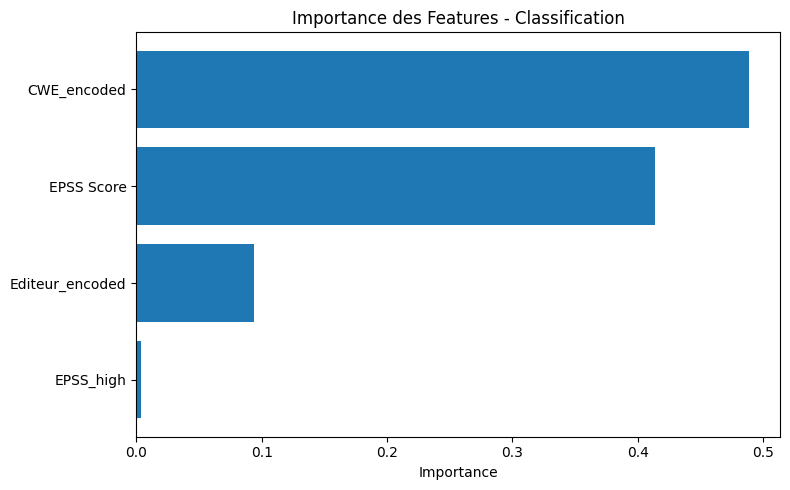

In [6]:
#Importance des features pour la classification

importances = rf_clf.feature_importances_                               #retourne un tableau indiquant l'importance en % de chaque caractéristique (colonne) pour les prédictions
feature_names = X.columns

fig, ax = plt.subplots(figsize = (8, 5))

sorted_idx = np.argsort(importances)                                    #argsort retourne les indices qui trieraient le tableau par ordre d'importnance

ax.barh(range(len(sorted_idx)), importances[sorted_idx])                #garphique bar horizontal

ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Importance')
ax.set_title('Importance des Features - Classification')
plt.tight_layout()
plt.show()

In [7]:
#Regression (predire le score CVSS exact)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size = 0.2, random_state= 42)

X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

rf_reg = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_reg.fit(X_train_r_scaled, y_train_r)

y_pred_r = rf_reg.predict(X_test_r_scaled)


print(f"R2 Score : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")
print(f"MAE : {np.mean(np.abs(y_test_r - y_pred_r)):.4f}")

print("\nComparaison :")
comparison = pd.DataFrame({'Reel': y_test_r[:10].values, 'Prediction': y_pred_r[:10]})
comparison['Erreur'] = comparison['Prediction'] - comparison['Reel']
print(comparison)

R2 Score : 0.4533
RMSE:  1.0771
MAE : 0.7146

Comparaison :
   Reel  Prediction        Erreur
0   7.8    7.337000 -4.630000e-01
1   8.2    8.079100 -1.209000e-01
2   4.7    4.894000  1.940000e-01
3   7.8    7.800000 -9.769963e-15
4   7.8    6.474000 -1.326000e+00
5   7.0    7.008000  8.000000e-03
6   7.8    7.644618 -1.553822e-01
7   8.8    7.930713 -8.692870e-01
8   9.8    7.989000 -1.811000e+00
9   5.5    5.549000  4.900000e-02


In [8]:
#Validation croisee des modeles

from sklearn.model_selection import cross_val_score


cv_scores_clf = cross_val_score(rf_clf, X_train_scaled, y_train, cv = 5)                                    #Divise les données d'entraînement en 5 folds, entraînant le modèle sur 4 folds et testant sur le fold restant et répète cela pour chaque fold. 
                                                                                                            #Retourne un tableau de scores (accuracy dans ce cas) pour chaque fold.


print(f"Classification Accuracy moyenne : {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std():.4f})")
print(f"Scores par fold : {cv_scores_clf}")

# Validation croisee regression
cv_scores_reg = cross_val_score(rf_reg, X_train_r_scaled, y_train_r, cv = 5, scoring = 'r2')
print(f"\nRegression R2 moyen : {cv_scores_reg.mean():.4f} (+/- {cv_scores_reg.std():.4f})")

Classification Accuracy moyenne : 0.8723 (+/- 0.0159)
Scores par fold : [0.88235294 0.87058824 0.87058824 0.8452381  0.89285714]

Regression R2 moyen : 0.3876 (+/- 0.0825)


In [9]:
#Optimisation avec GridSearch

param_grid = {
    'n_estimators' : [50, 100, 150],
    'max_depth' : [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


#GridSearchCV = teste toutes les combinaisons de paramètres spécifiées dans param_grid, en utilisant la validation croisée pour évaluer les performances de chaque combinaison
grid_search = GridSearchCV(RandomForestClassifier(random_state = 42), param_grid, cv = 5, scoring = 'accuracy') #cv = 5 pour 5 folds, scoring = evaluation metric
grid_search.fit(X_train_scaled, y_train)


print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score : {grid_search.best_score_:.4f}")



best_model = grid_search.best_estimator_                                                                        #.best_estimator_ = retourne le modèle entraîné avec les meilleurs paramètres trouvés par GridSearchCV
y_pred_best = best_model.predict(X_test_scaled)
print(f"Accuracy sur test avec meilleur modèle : {accuracy_score(y_test, y_pred_best):.4f}")

Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score : 0.8723
Accuracy sur test avec meilleur modèle : 0.8774


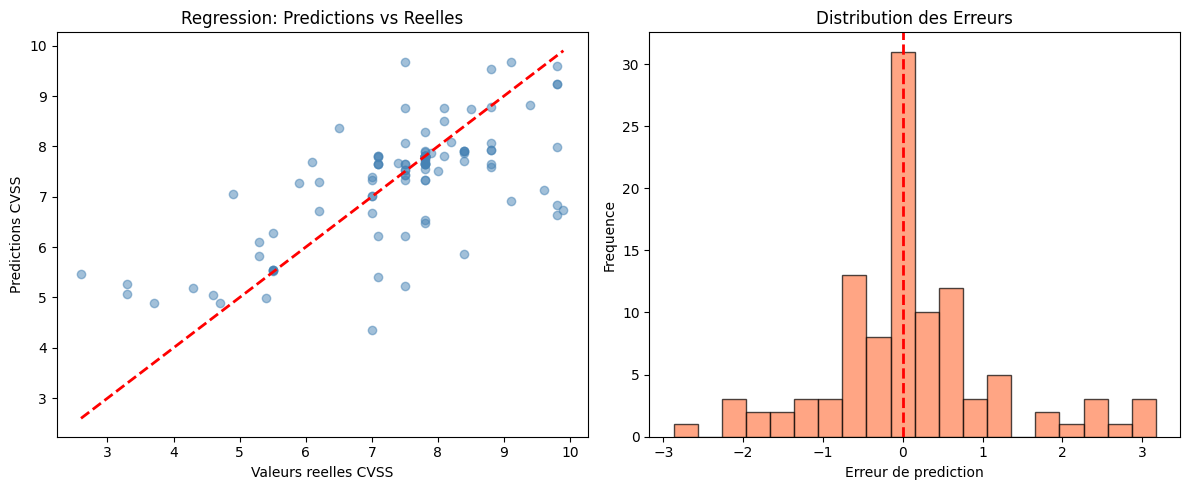

In [ ]:
#Visualisation des predictions vs valeurs reelles (regression)

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Scatter plot predictions vs reelles
axes[0].scatter(y_test_r, y_pred_r, alpha = 0.5, color = 'steelblue')
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw = 2)
axes[0].set_xlabel('Valeurs reelles CVSS')
axes[0].set_ylabel('Predictions CVSS')
axes[0].set_title('Regression Predictions vs Reelles')

# Histogramme des erreurs
errors = y_test_r - y_pred_r
axes[1].hist(errors, bins = 20, edgecolor = 'black', alpha = 0.7, color = 'coral')
axes[1].axvline(x = 0, color = 'red', linestyle = '--', linewidth = 2)
axes[1].set_xlabel('Erreur de prediction')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des Erreurs')

plt.tight_layout()
plt.show()

In [12]:
#Comparaison avec un modele plus simple (baseline)

from sklearn.dummy import DummyClassifier, DummyRegressor

# Baseline classification (predire toujours la classe majoritaire)
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(X_train_scaled, y_train)
y_pred_dummy = dummy_clf.predict(X_test_scaled)

# Baseline regression (predire toujours la moyenne)
dummy_reg = DummyRegressor(strategy = 'mean')
dummy_reg.fit(X_train_r_scaled, y_train_r)
y_pred_dummy_reg = dummy_reg.predict(X_test_r_scaled)



print(f"Classification Baseline (classe majoritaire): {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Classification Random Forest: {accuracy_score(y_test, y_pred):.4f}")
print(f"Amelioration: +{(accuracy_score(y_test, y_pred) - accuracy_score(y_test, y_pred_dummy))*100:.1f}%")

print(f"\nRegression Baseline (moyenne): {r2_score(y_test_r, y_pred_dummy_reg):.4f}")
print(f"Regression Random Forest: {r2_score(y_test_r, y_pred_r):.4f}")

Classification Baseline (classe majoritaire): 0.7642
Classification Random Forest: 0.8774
Amelioration: +11.3%

Regression Baseline (moyenne): -0.0045
Regression Random Forest: 0.4533


In [13]:
#Export du modele

import joblib

# Sauvegarder le meilleur modele
joblib.dump(best_model, 'modele_classification_cvss.pkl')
joblib.dump(scaler, 'scaler_cvss.pkl')
joblib.dump(le_editeur, 'label_encoder_editeur.pkl')

print("Modeles sauvegardes:")
print("modele_classification_cvss.pkl")
print("scaler_cvss.pkl")
print("label_encoder_editeur.pkl")


loaded_model = joblib.load('modele_classification_cvss.pkl')
print("\nTest chargement: OK")

Modeles sauvegardes:
modele_classification_cvss.pkl
scaler_cvss.pkl
label_encoder_editeur.pkl

Test chargement: OK


In [14]:
#Exemple de prediction sur une nouvelle vulnerabilite

def predict_vulnerability(epss_score, editeur, cwe):
    input_data = pd.DataFrame({
        'EPSS Score': [epss_score],
        'EPSS_high': [1 if epss_score > 0.01 else 0],
        'Editeur_encoded': [le_editeur.transform([editeur])[0] if editeur in le_editeur.classes_ else le_editeur.transform(['Autre'])[0]],
        'CWE_encoded': [le_cwe.transform([cwe])[0] if cwe in le_cwe.classes_ else le_cwe.transform(['Non disponible'])[0]]
    })
    input_scaled = scaler.transform(input_data)
    prediction = best_model.predict(input_scaled)[0]
    proba = best_model.predict_proba(input_scaled)[0]
    return prediction, proba




test_cases = [(0.05, 'Microsoft', 'CWE-79'), (0.001, 'Cisco', 'CWE-89'), (0.0001, 'Autre', 'Non disponible')]

for epss, editeur, cwe in test_cases:
    pred, proba = predict_vulnerability(epss, editeur, cwe)
    status = "Critique (CVSS >= 7)" if pred == 1 else "Non critique (CVSS < 7)"
    confidence = proba[pred]
    print(f"EPSS = {epss}, Editeur = {editeur}, CWE = {cwe}")
    print(f"Prediction : {status} (confiance : {confidence:.1%})")
    print()

EPSS = 0.05, Editeur = Microsoft, CWE = CWE-79
Prediction : Critique (CVSS >= 7) (confiance : 99.0%)

EPSS = 0.001, Editeur = Cisco, CWE = CWE-89
Prediction : Non critique (CVSS < 7) (confiance : 62.0%)

EPSS = 0.0001, Editeur = Autre, CWE = Non disponible
Prediction : Non critique (CVSS < 7) (confiance : 60.5%)

